<div style="background:#0A2540;color:white;padding:18px 22px;border-radius:8px"><div style="color:#F4B942;font-weight:700;letter-spacing:1px">WEEK 6 · TUTORIAL 3 (LIVE SCRIPT)</div><div style="font-size:24px;font-weight:800;margin:4px 0">Model Evaluation — Metrics for Triage</div><div style="opacity:.9">Choose and justify the right metric for an imbalanced, safety-critical problem.</div><div style="margin-top:8px;font-size:13px;opacity:.75">Audience: Caribbean Clinical-AI trainees · Mercer General Hospital · dataset: Yale EMMLC (cleaned)</div></div>

### What you'll do today
1. Rebuild your two models from Tutorial 2 (so this notebook runs on its own).
2. Read a **confusion matrix** in a triage context.
3. Compute **accuracy, precision, recall, F1** — and understand what each means clinically.
4. Learn why **recall for ESI 1** is the number that matters most.
5. Build a small comparison table and save your confusion-matrix figure.

<div style="border-left:6px solid #1B9AAA;background:#1B9AAA14;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#1B9AAA">🩺 CLINICAL CONTEXT</b><br>A false negative for an <b>ESI 1</b> patient means the model called a dying patient ‘not urgent’. That is not the same kind of mistake as over-calling a stable patient. Today is about measuring the mistakes that actually hurt people — not just counting how often we're right.</div>

In [24]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: loads the Python "tools" (libraries) we need.
#   - pandas: works with tables of data (like a spreadsheet in code)
#   - matplotlib: draws charts
#   - scikit-learn (sklearn): the machine-learning toolkit
#   - joblib: saves a trained model to a file so we can reuse it later
# You only run this once at the top of the notebook.
# ------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

pd.set_option("display.width", 120)
print("Libraries loaded. ✅")

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, f1_score, recall_score,
)

Libraries loaded. ✅


In [3]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: loads the CLEANED dataset you produced in Week 5
# (triage_cleaned_v1.csv). Every row is one patient visit; every column
# is something we measured (age, vitals, chief-complaint flags, ESI...).
# In Colab, make sure this file is in the same folder (or mount Drive).
# ------------------------------------------------------------------

# mount Drive
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/Carisurg/triage_cleaned_v1.csv")
print("Loaded", df.shape[0], "patients and", df.shape[1], "columns.")
df.head()

Mounted at /content/drive
Loaded 55121 patients and 225 columns.


,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,A,4,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,B,2,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,A,2,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,A,3,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,A,2,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br>We rebuild the same X/y, the same split, and the same two models as Tutorial 2. Because we reuse the same <code>random_state</code>, we get the <i>identical</i> split — that's what makes results reproducible. If you saved your models with joblib, you could <code>joblib.load</code> them instead.</div>

In [4]:
TARGET = "esi"

# OUTCOMES of the visit — known only AFTER triage, so they must never be model inputs:
LEAKAGE = ["disposition", "previousdispo"]

NON_NUMERIC = [
    "dep_name",
    "gender",
    "ethnicity",
    "race",
    "lang",
    "religion",
    "maritalstatus",
    "employstatus",
    "insurance_status",
    "arrivalmode",
    "arrivalmonth",
    "arrivalday",
    "arrivalhour_bin"
]
# Every column that is NOT the target, NOT leakage,
# and NOT non-numeric is treated as a feature.
FEATURES = [
    c for c in df.columns
    if c != TARGET
    and c not in LEAKAGE
    and c not in NON_NUMERIC
]

X = df[FEATURES]
y = df[TARGET]

print("Model will use", len(FEATURES), "features to predict:", TARGET)
print("First few features:", FEATURES[:6], "...")

Model will use 209 features to predict: esi
First few features: ['age', 'triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_rr', 'triage_vital_o2'] ...


In [5]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: recreates Tutorial 2's features, split, and models,
# so Tutorial 3 stands on its own. Same random_state = same split.
# ------------------------------------------------------------------
X, y = df[FEATURES], df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# Logistic regression needs scaling; the tree does not.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_s, y_train)
tree   = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train, y_train)
dummy  = DummyClassifier(strategy="stratified", random_state=42).fit(X_train, y_train)
print("Models ready. ✅")

Models ready. ✅


## 1 · Make predictions on the test set

<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br><code>.predict(...)</code> asks a trained model for its ESI guess on each test patient. Remember logistic regression must see the <b>scaled</b> test features (<code>X_test_s</code>), while the tree uses the original <code>X_test</code>.</div>

In [6]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: gets each model's predicted ESI for the test set.
# ------------------------------------------------------------------
pred_logreg = logreg.predict(X_test_s)   # scaled features for LR
pred_tree   = tree.predict(X_test)       # unscaled for the tree
pred_dummy = dummy.predict(X_test)
print("Example predictions (logreg):", pred_logreg[:10])
print("Example predictions (decision tree):", pred_tree[:10])
print("Example predictions (dummy):", pred_dummy[:10])

Example predictions (logreg): [2 3 3 2 2 2 3 3 3 2]
Example predictions (decision tree): [2 3 3 3 3 3 3 3 3 3]
Example predictions (dummy): [2 3 4 4 3 3 3 3 3 3]


In [7]:
# Calculate weighted F1 for each model, giving more influence to the common ESI classes
from sklearn.metrics import f1_score

dummy_weighted_f1 = f1_score(y_test, pred_dummy, average="weighted")
logreg_weighted_f1 = f1_score(y_test, pred_logreg, average="weighted")
tree_weighted_f1 = f1_score(y_test, pred_tree, average="weighted")

print("Dummy Weighted F1:", round(dummy_weighted_f1, 3))
print("Logistic Regression Weighted F1:", round(logreg_weighted_f1, 3))
print("Decision Tree Weighted F1:", round(tree_weighted_f1, 3))

Dummy Weighted F1: 0.375
Logistic Regression Weighted F1: 0.677
Decision Tree Weighted F1: 0.449


## 2 · The confusion matrix

📚 **scikit-learn docs:** [`confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)  ·  [`ConfusionMatrixDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)

Before you plot your own, here is how to read one. Our real matrix has all five ESI levels, but the idea is clearest with a single class — 'urgent' vs 'not':

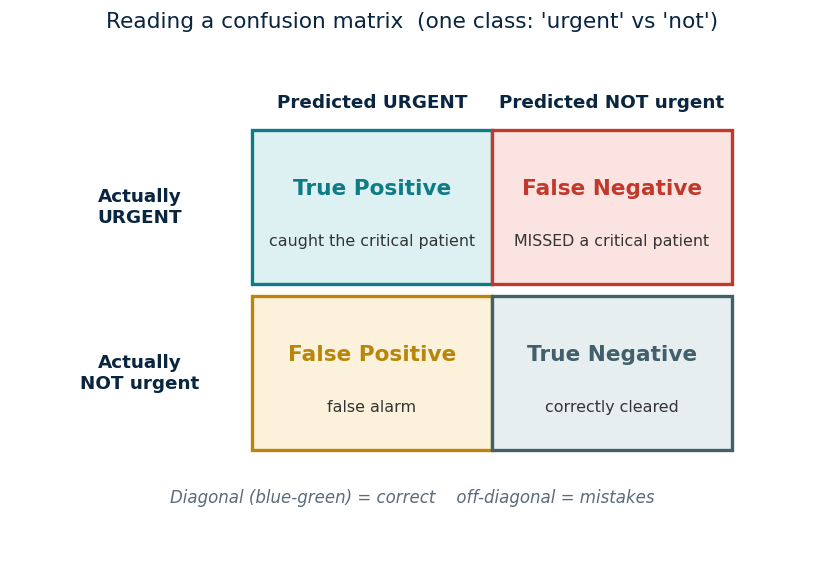

<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br>A <b>confusion matrix</b> is a grid: rows are the <i>true</i> ESI level, columns are what the model <i>predicted</i>. The diagonal is where it got it right. Everything off the diagonal is a mistake — and the matrix shows you <i>which</i> levels get confused for which. That detail is invisible in a single accuracy number.</div>

<div style="border-left:6px solid #F4B942;background:#F4B94214;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#F4B942">✏️ YOUR TASK</b><br>Draw the confusion matrix for the logistic-regression predictions using <code>ConfusionMatrixDisplay.from_predictions(...)</code>.</div>

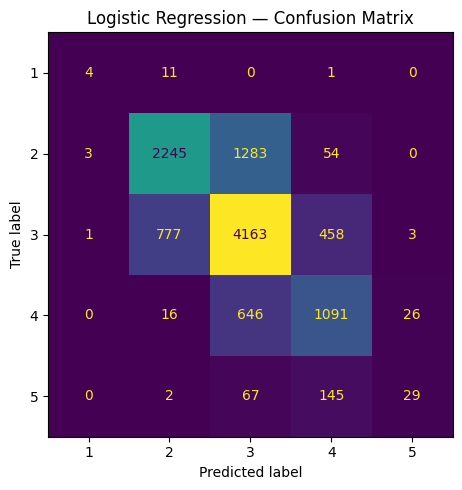

In [8]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: draws the confusion matrix for logistic regression.
# Rows = true ESI, columns = predicted ESI. Diagonal = correct.
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_logreg,
    ax=ax,
    colorbar=False
)

ax.set_title("Logistic Regression — Confusion Matrix")

plt.tight_layout()
plt.show()

The logistic regression model correctly identified 4 of the 16 true ESI Level 1 encounters, giving an ESI 1 recall of 0.25. It performed better than the other models but still missed 12 of the most critical patients.


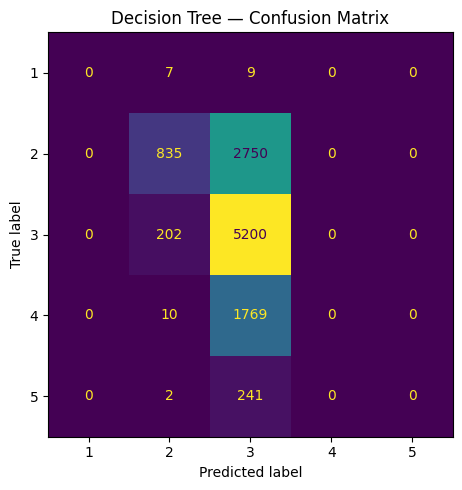

Saved figs/w6_confusion_tree.png ✅


In [9]:
# Plot and save the decision-tree confusion matrix
import os
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_tree,
    ax=ax,
    colorbar=False
)

os.makedirs("figs", exist_ok=True)

ax.set_title("Decision Tree — Confusion Matrix")

plt.tight_layout()
plt.savefig(
    "figs/w6_confusion_tree.png",
    dpi=110,
    bbox_inches="tight"
)

plt.show()

print("Saved figs/w6_confusion_tree.png ✅")

The decision tree predicts almost every patient as ESI 2 or 3, especially ESI 3, and completely fails to correctly identify any ESI 1, 4, or 5 cases. This shows that the model is heavily biased toward the most common middle-acuity classes and does a poor job separating the full range of triage levels.


## 3 · Accuracy, precision, recall, F1

📚 **scikit-learn docs:** [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)  ·  [`Precision, recall & F-measures (user guide)`](https://scikit-learn.org/stable/modules/model_evaluation.html#precision-recall-f-measure-metrics)

This picture is the one to remember. **Precision** and **recall** both count the same true positives (TP) — they just divide by different things. Precision asks *‘of what I flagged, how much was right?’* (a column); recall asks *‘of what was truly urgent, how much did I catch?’* (a row).

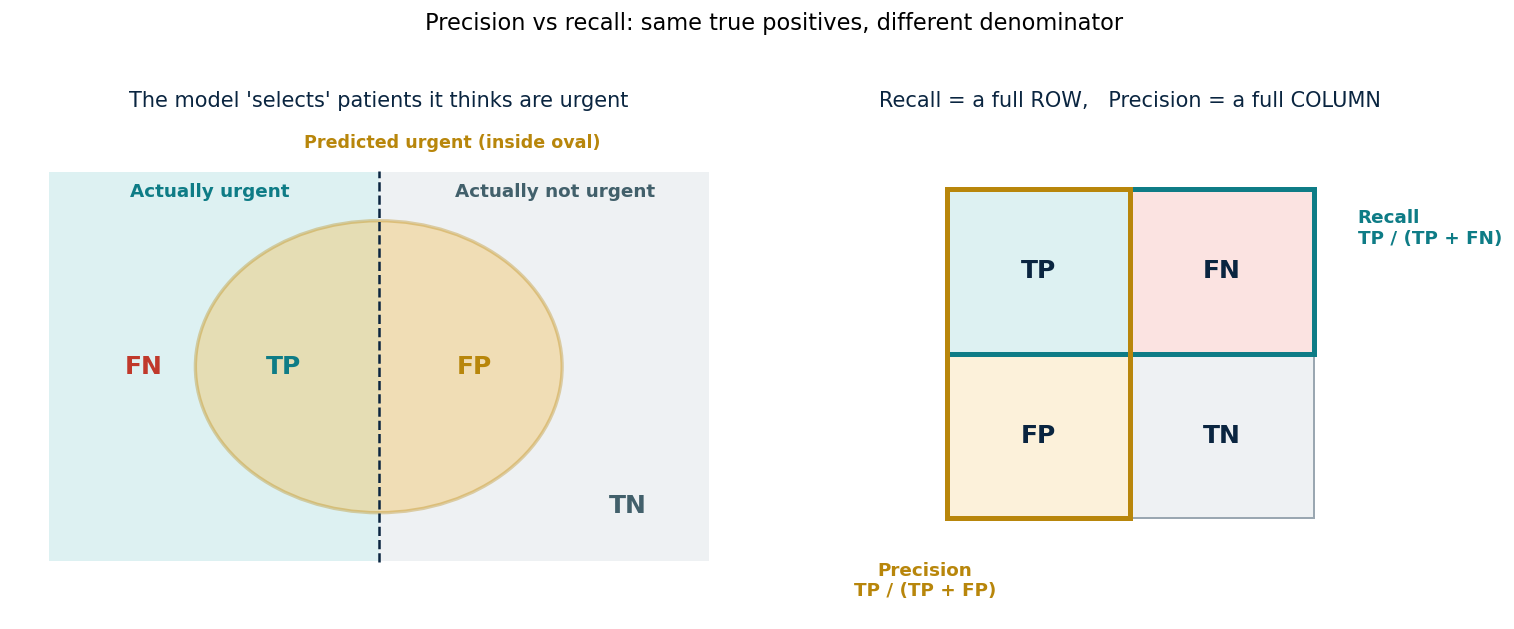

<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br>Four words, plain English, for one class at a time:<br>• <b>Accuracy</b> — of all patients, what fraction did we label correctly? (whole-dataset)<br>• <b>Precision</b> — when the model <i>says</i> ESI 1, how often is it right? (few false alarms)<br>• <b>Recall</b> — of the patients who <i>really are</i> ESI 1, how many did we catch? (few misses)<br>• <b>F1</b> — a single score that balances precision and recall.</div>

<div style="border-left:6px solid #F4B942;background:#F4B94214;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#F4B942">✏️ YOUR TASK</b><br>Print the full <code>classification_report(...)</code> for the logistic-regression predictions — it lists precision, recall and F1 for every ESI level at once.</div>

In [10]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: prints precision / recall / F1 for EACH ESI level.
# ------------------------------------------------------------------
print(
    classification_report(
        y_test,
        pred_logreg,
        digits=3
    )
)

              precision    recall  f1-score   support

           1      0.500     0.250     0.333        16
           2      0.736     0.626     0.677      3585
           3      0.676     0.771     0.720      5402
           4      0.624     0.613     0.618      1779
           5      0.500     0.119     0.193       243

    accuracy                          0.683     11025
   macro avg      0.607     0.476     0.508     11025
weighted avg      0.683     0.683     0.677     11025



## 4 · Macro vs weighted F1

📚 **scikit-learn docs:** [`f1_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)

The two averages weight the classes differently — and that choice decides whether the rare, critical ESI 1 gets a real say:

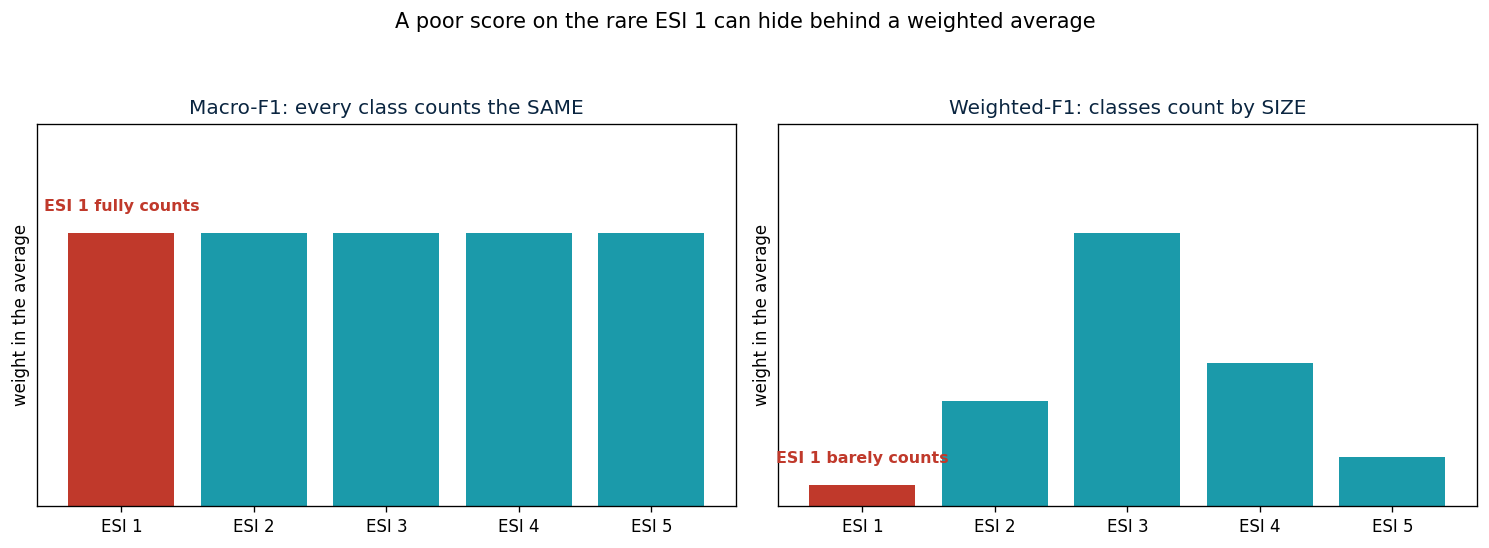

<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br>There are two ways to average F1 across the 5 ESI levels. <b>Weighted</b> F1 gives big classes more say — so a great score on the common ESI 3 can hide a terrible score on the rare ESI 1. <b>Macro</b> F1 treats every class equally, so the rare-but-critical classes can't be swept under the rug. For triage we lean on <b>macro</b>.</div>

<div style="border-left:6px solid #F4B942;background:#F4B94214;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#F4B942">✏️ YOUR TASK</b><br>Compute both averages with <code>f1_score(...)</code> using <code>average="macro"</code> and <code>average="weighted"</code>, and print them side by side.</div>

In [11]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: compares the two ways of averaging F1.
# macro = every ESI level counts equally; weighted = big classes dominate.
# ------------------------------------------------------------------
macro_f1 = f1_score(
    y_test,
    pred_logreg,
    average="macro"
)

weighted_f1 = f1_score(
    y_test,
    pred_logreg,
    average="weighted"
)

print("Macro F1:   ", round(macro_f1, 3))
print("Weighted F1:", round(weighted_f1, 3))



Macro F1:    0.508
Weighted F1: 0.677


Macro F1 gives every ESI level equal importance, while weighted F1 gives more influence to the common ESI levels. The weighted F1 score is higher than the macro F1 score, showing that the model performed better on the more common ESI classes than on the rarer classes.


## 5 · The number that matters most: recall for ESI 1

📚 **scikit-learn docs:** [`recall_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html)

Why we obsess over this one number: recall for ESI 1 is literally the fraction of the sickest patients the model catches. Picture 20 truly-critical patients —

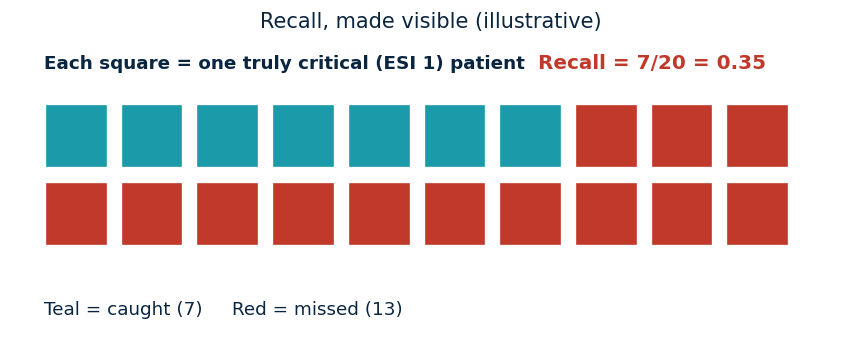

<div style="border-left:6px solid #1B9AAA;background:#1B9AAA14;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#1B9AAA">🩺 CLINICAL CONTEXT</b><br>If you remember one metric from this whole week, make it this: <b>recall for ESI 1</b> — the share of truly critical patients the model actually flags as critical. A missed ESI 1 is the failure mode with the worst clinical consequence.</div>

<div style="border-left:6px solid #F4B942;background:#F4B94214;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#F4B942">✏️ YOUR TASK</b><br>Use <code>recall_score(...)</code> with <code>labels=[1]</code> and <code>average=None</code> to pull out the recall for ESI level 1 specifically (compare logistic regression vs the tree).</div>

In [12]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: extracts recall for ESI level 1 for each model.
# recall_score(..., labels=[1], average=None) returns a list with just
# the ESI-1 recall, so we take element [0].
# ------------------------------------------------------------------
logreg_esi1_recall = recall_score(
    y_test,
    pred_logreg,
    labels=[1],
    average=None
)[0]

tree_esi1_recall = recall_score(
    y_test,
    pred_tree,
    labels=[1],
    average=None
)[0]

print(
    "Logistic regression ESI 1 recall:",
    round(logreg_esi1_recall, 3)
)

print(
    "Decision tree ESI 1 recall:",
    round(tree_esi1_recall, 3)
)

Logistic regression ESI 1 recall: 0.25
Decision tree ESI 1 recall: 0.0


ESI 1 recall is the proportion of truly critical ESI 1 encounters that the model correctly identifies.

## 6 · Compare the models at a glance

In [13]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: Collects the main evaluation metrics in one table so the dummy baseline,
# logistic regression, and decision tree can be compared easily.
# ------------------------------------------------------------------
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, recall_score

def summarise(name, preds):
    return {
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, preds), 3),
        "Macro F1": round(f1_score(y_test, preds, average="macro"), 3),
        "Weighted F1": round(f1_score(y_test, preds, average="weighted"), 3),
        "ESI 1 Recall": round(
            recall_score(
                y_test,
                preds,
                labels=[1],
                average=None,
                zero_division=0
            )[0],
            3
        )
    }

comparison_table = pd.DataFrame([
    summarise("Dummy Classifier", pred_dummy),
    summarise("Logistic Regression", pred_logreg),
    summarise("Decision Tree", pred_tree)
])

comparison_table

,Model,Accuracy,Macro F1,Weighted F1,ESI 1 Recall
0,Dummy Classifier,0.375,0.204,0.375,0.00
1,Logistic Regression,0.683,0.508,0.677,0.25
2,Decision Tree,0.547,0.207,0.449,0.00


<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br>This little helper runs the same three measurements on each model and stacks them into a table with <code>pd.DataFrame([...])</code>. A comparison table like this is the heart of your Week 6 baseline report — it shows, honestly, that the real models beat the dummy and where they still fall short.</div>

## 7 · Save your confusion-matrix figure

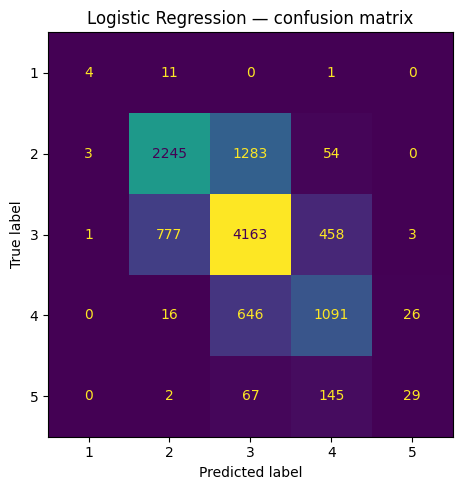

Saved figs/w6_confusion_logreg.png ✅


In [14]:
# ------------------------------------------------------------------
# WHAT THIS CELL DOES: saves the confusion matrix to figs/ so you can
# commit it to GitHub and drop it into your report.
# ------------------------------------------------------------------
import os
os.makedirs("figs", exist_ok=True)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_logreg, ax=ax, colorbar=False)
ax.set_title("Logistic Regression — confusion matrix")
plt.tight_layout()
plt.savefig("figs/w6_confusion_logreg.png", dpi=110)
plt.show()
print("Saved figs/w6_confusion_logreg.png ✅")

## 8 · Exercises
1. Draw the confusion matrix for the **decision tree** too. Which levels does it confuse most?
2. Which model would you trust more for triage, and **why** — quote a specific number.
3. In one sentence, explain to a nurse why **accuracy alone** is not enough here.

Commit your notebook and the saved figure to your repo.

#2. Which model would you trust more?

I would trust logistic regression more as the stronger baseline because it performed better across every reported metric and, most importantly, correctly identified 4 of the 16 ESI Level 1 patients. The decision tree missed all 16 critical cases and mostly predicted patients as ESI 2 or 3, showing that it could not reliably separate the full range of triage levels. However, logistic regression’s ESI 1 recall of 0.25 is still too low for clinical use.


#3. Why accuracy alone is not enough

Accuracy alone is not enough because a model can correctly classify many common, lower-risk patients while still missing the rare ESI 1 patients who need immediate care.

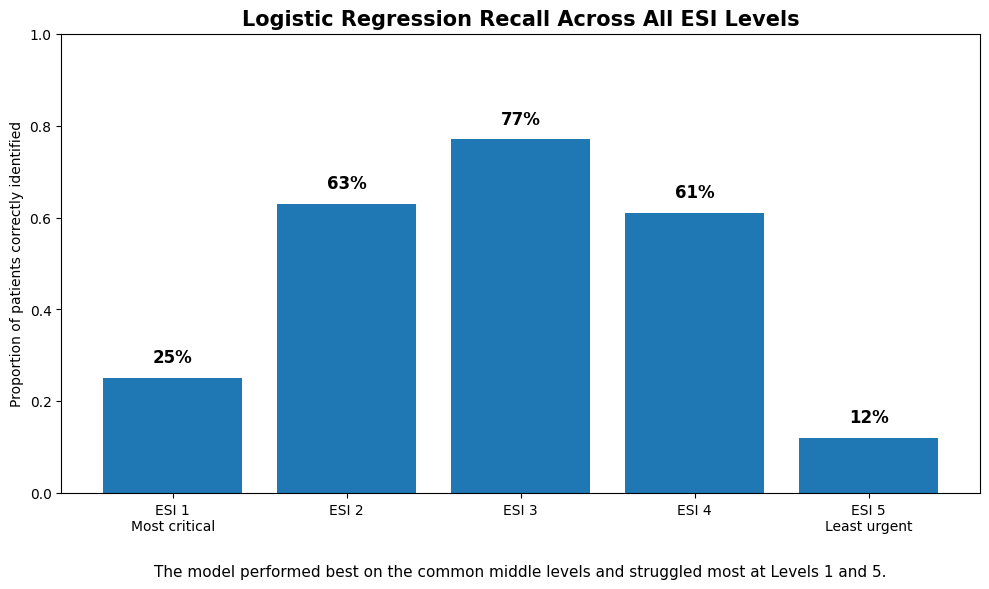

Saved as figs/logreg_recall_all_esi_levels.png


In [26]:
import matplotlib.pyplot as plt
from pathlib import Path

# Create output folder
output_folder = Path("figs")
output_folder.mkdir(parents=True, exist_ok=True)

# Logistic regression recall for each ESI level
esi_levels = [
    "ESI 1\nMost critical",
    "ESI 2",
    "ESI 3",
    "ESI 4",
    "ESI 5\nLeast urgent"
]

recall_scores = [0.25, 0.63, 0.77, 0.61, 0.12]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(esi_levels, recall_scores)

ax.set_title(
    "Logistic Regression Recall Across All ESI Levels",
    fontsize=15,
    fontweight="bold"
)
ax.set_ylabel("Proportion of patients correctly identified")
ax.set_ylim(0, 1)

# Add percentage labels above each bar
for bar, score in zip(bars, recall_scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.025,
        f"{score:.0%}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

ax.text(
    0.5,
    -0.18,
    "The model performed best on the common middle levels and struggled most at Levels 1 and 5.",
    transform=ax.transAxes,
    ha="center",
    fontsize=11
)

plt.tight_layout()

plt.savefig(
    output_folder / "logreg_recall_all_esi_levels.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved as figs/logreg_recall_all_esi_levels.png")

Logistic regression performed best on the common middle ESI levels, correctly identifying 63% of ESI 2, 77% of ESI 3 and 61% of ESI 4 patients. Its performance was much weaker for the rarer extreme categories, identifying only 25% of ESI 1 patients and 12% of ESI 5 patients. This suggests that the model is influenced by the class imbalance and has greater difficulty learning patterns for categories with fewer examples. The low recall for ESI 1 is the most clinically concerning because missed cases could result in critically ill patients receiving a lower triage priority.

# Explore the ESI Level 1 cases

There are very few ESI Level 1 patients in the test set, so I reviewed their chief complaints, vital signs and model predictions more closely. This may help explain why some critical patients were missed and identify features that could improve the models.

In [15]:
# Create a table containing only the true ESI Level 1 patients
esi1_cases = X_test.loc[y_test == 1].copy()

# Add the true label and each model's prediction
esi1_cases["True ESI"] = y_test.loc[y_test == 1]
esi1_cases["Logistic Prediction"] = pred_logreg[y_test == 1]
esi1_cases["Tree Prediction"] = pred_tree[y_test == 1]

print("Number of ESI Level 1 patients in the test set:", len(esi1_cases))

esi1_cases

Number of ESI Level 1 patients in the test set: 16


,age,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,...,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain,True ESI,Logistic Prediction,Tree Prediction
40313,74.0,78.0,168.0,88.0,18.0,98.0,0.0,97.0,100.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,2,3
595,81.0,76.0,93.0,60.0,18.0,96.0,0.0,97.8,94.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,2,3
51171,67.0,81.0,156.0,138.0,22.0,97.0,0.0,97.8,120.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,3
294,88.0,135.0,86.0,55.0,38.0,83.0,1.0,99.0,160.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,2,2
27022,73.0,118.0,201.0,101.0,16.0,99.0,1.0,95.3,121.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,2,2
15529,90.0,65.0,74.0,39.0,14.0,96.0,0.0,97.8,113.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,2,3
48302,67.0,51.0,99.0,48.0,16.0,98.0,1.0,96.3,211.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,2,2
15923,51.0,81.0,182.0,131.0,18.0,96.0,0.0,96.5,72.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,2,3
19964,52.0,84.0,162.0,90.0,17.0,99.0,0.0,97.2,101.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,4,3
40192,103.0,68.0,195.5,65.5,17.0,97.0,0.0,98.0,118.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,2,3


## Review ESI 1 vital signs and chief complaints


In [16]:
# Identify vital-sign and chief-complaint columns
vital_columns = [
    c for c in FEATURES
    if "triage_vital" in c.lower()
]

chief_complaint_columns = [
    c for c in FEATURES
    if c.lower().startswith("cc_")
]

print("Vital-sign columns:")
print(vital_columns)

print("\nNumber of chief-complaint columns:", len(chief_complaint_columns))

Vital-sign columns:
['triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_rr', 'triage_vital_o2', 'triage_vital_o2_device', 'triage_vital_temp']

Number of chief-complaint columns: 200


In [17]:
# Summarise the vital signs for the ESI 1 group
esi1_vitals = esi1_cases[vital_columns]

esi1_vitals.describe().T

,count,mean,std,min,25%,50%,75%,max
triage_vital_hr,16.0,87.59375,25.083340,51.0,69.125,81.0,100.000,135.0
triage_vital_sbp,16.0,152.56250,45.683285,74.0,120.750,159.0,189.125,221.0
triage_vital_dbp,16.0,81.75000,29.532468,39.0,58.875,77.0,102.750,138.0
triage_vital_rr,16.0,20.96875,6.919703,14.0,17.000,18.0,22.000,38.0
triage_vital_o2,16.0,96.56250,3.794184,83.0,96.000,97.0,98.250,99.0
triage_vital_o2_device,16.0,0.43750,0.512348,0.0,0.000,0.0,1.000,1.0
triage_vital_temp,16.0,97.46875,0.914854,95.3,96.925,97.8,98.000,99.0


In [18]:
# ESI 1 versus the other levels
vital_comparison = df.groupby("esi")[vital_columns].median().T

vital_comparison.columns = [
    f"ESI {int(level)}" for level in vital_comparison.columns
]

vital_comparison


,ESI 1,ESI 2,ESI 3,ESI 4,ESI 5
triage_vital_hr,84.0,87.0,85.0,84.0,83.0
triage_vital_sbp,139.0,131.0,133.0,131.0,129.0
triage_vital_dbp,77.0,78.0,79.0,80.0,79.0
triage_vital_rr,18.0,18.0,18.0,18.0,18.0
triage_vital_o2,97.0,97.0,98.0,98.0,98.0
triage_vital_o2_device,0.0,0.0,0.0,0.0,0.0
triage_vital_temp,97.7,98.0,98.1,98.0,98.0


## Most common ESI 1 chief complaints

In [19]:
# Count and rank the chief complaints recorded among true ESI 1 patients
esi1_chief_complaints = (
    esi1_cases[chief_complaint_columns]
    .sum()
    .sort_values(ascending=False)
)

esi1_chief_complaints = esi1_chief_complaints[
    esi1_chief_complaints > 0
]

esi1_chief_complaints.head(15)

# Display clearly
esi1_chief_complaints.head(15).to_frame(
    name="Number of ESI 1 Patients"
)

,Number of ESI 1 Patients
cc_strokealert,5.0
cc_other,4.0
cc_shortnessofbreath,2.0
cc_dizziness,1.0
cc_mass,1.0
cc_alteredmentalstatus,1.0
cc_hypotension,1.0
cc_poisoning,1.0
cc_respiratorydistress,1.0
cc_neurologicproblem,1.0


## Compare correctly identified and missed ESI 1 patients

In [27]:
# Separate the ESI 1 patients into those correctly identified and those missed
esi1_cases["Logistic Correct"] = (
    esi1_cases["Logistic Prediction"] == 1
)

caught_esi1 = esi1_cases[
    esi1_cases["Logistic Correct"]
]

missed_esi1 = esi1_cases[
    ~esi1_cases["Logistic Correct"]
]

print("Total ESI 1 patients:", len(esi1_cases))
print("ESI 1 patients correctly identified:", len(caught_esi1))
print("ESI 1 patients missed:", len(missed_esi1))

Total ESI 1 patients: 16
ESI 1 patients correctly identified: 4
ESI 1 patients missed: 12


In [21]:
# Compare their vital signs
caught_vitals = caught_esi1[vital_columns].median()
missed_vitals = missed_esi1[vital_columns].median()

esi1_vital_comparison = pd.DataFrame({
    "Caught ESI 1 Median": caught_vitals,
    "Missed ESI 1 Median": missed_vitals
})

esi1_vital_comparison

,Caught ESI 1 Median,Missed ESI 1 Median
triage_vital_hr,75.25,82.50
triage_vital_sbp,148.25,165.00
triage_vital_dbp,93.50,71.75
triage_vital_rr,20.25,18.00
triage_vital_o2,97.50,97.00
triage_vital_o2_device,0.50,0.00
triage_vital_temp,97.95,97.75


In [22]:
# Compare their chief complaints
caught_complaints = (
    caught_esi1[chief_complaint_columns]
    .sum()
    .sort_values(ascending=False)
)

missed_complaints = (
    missed_esi1[chief_complaint_columns]
    .sum()
    .sort_values(ascending=False)
)

complaint_comparison = pd.DataFrame({
    "Caught ESI 1": caught_complaints,
    "Missed ESI 1": missed_complaints
}).fillna(0)

complaint_comparison[
    complaint_comparison.sum(axis=1) > 0
].sort_values(
    "Missed ESI 1",
    ascending=False
).head(15)

,Caught ESI 1,Missed ESI 1
cc_other,0.0,4.0
cc_shortnessofbreath,0.0,2.0
cc_alteredmentalstatus,0.0,1.0
cc_hypotension,0.0,1.0
cc_dizziness,0.0,1.0
cc_neurologicproblem,0.0,1.0
cc_mass,0.0,1.0
cc_poisoning,0.0,1.0
cc_respiratorydistress,0.0,1.0
cc_strokealert,4.0,1.0


## ESI Level 1 Analysis Summary

The ESI Level 1 cases were reviewed to examine their chief complaints, vital signs and model predictions. Logistic regression correctly identified 4 of the 16 cases, while the remaining 12 were assigned to other ESI levels. Because the number of ESI Level 1 cases is very small, these results should be interpreted carefully. However, the patterns observed may help guide future feature development and model improvements.

Future work will include testing advanced classifiers, tuning hyperparameters, comparing models using a wider range of measures and carrying out further error analysis.

## 📚 Further reading — scikit-learn documentation

Every scikit-learn tool used in this notebook, linked to its official reference. When a function has more options than we used here, this is where to look them up.
- [`confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
- [`ConfusionMatrixDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)
- [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)
- [`f1_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)
- [`recall_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html)
- [`Precision, recall & F-measures (user guide)`](https://scikit-learn.org/stable/modules/model_evaluation.html#precision-recall-f-measure-metrics)